# Function 6

<b> Description of the Sample Application:</b> You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. 
To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sums



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Reused the Week 2 consolidated bayesian_optimization_step() function with β lowered to 1.5 (balanced explore/exploit).<br>3. Added kernel/length-scale diagnostics to check whether the model's sense of 'important ingredients' is stabilising.<br>4. Added Week 3 convergence, parallel-coordinates and UCB-slice visualisations.<br>7. Added Week 3 portal submission string. |


## Progress Log

| Week | Query Point (x) | Output (y) | Acquisition / β | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| Week 1 | 0.409594-0.023713-0.771229-0.966490-0.130973 | **-0.710675** | UCB, β = 2.5 (high exploration) | Slight improvement over the initial best (-0.714265); high β used deliberately since only 20 points were available in 5D |
| Week 2 | 0.408768-0.000000-0.999999-0.999999-0.000000 | -1.048677 | UCB, β = 2.0 | Worse than the current best, and worse than the GP's own predicted mean (-0.296). The corner-point extrapolation (eggs-butter maxed, sugar-milk minimised) did not pay off — a useful signal that the RBF surrogate's smoothness assumption may not hold well at the boundary. Current best remains Week 1's point. |
| Week 3 | - | - | UCB, β = 1.5 (balanced explore:exploit) | Lowering β further, added kernel length-scales checks to see if ingredient-importance rankings are still stable before leaning further into exploitation |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.optimize import minimize

from plotting_utils import plot_convergence, plot_parallel_coordinates

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [6]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [8]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.409594, 0.023713, 0.771229, 0.96649 , 0.130973 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.710675183457194]                                  , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.408768, 0.      , 0.999999, 0.999999, 0.       ]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-1.048676669557473]                                  , dtype=np.float64)    # from output.txt

In [10]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                              ])

In [12]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [25]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx        = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
ingredient_names = ["flour", "sugar", "eggs", "butter", "milk"]
df               = pd.DataFrame(X, columns = [ingredient_names])
df['Y']          = Y
print("Data Frame:\n", df)

Input  Shape: (22, 5)
Inputs:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.7049

# Data Exploration

In [28]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
            flour      sugar       eggs     butter       milk          Y
count  22.000000  22.000000  22.000000  22.000000  22.000000  22.000000
mean    0.535167   0.512505   0.505253   0.575234   0.391176  -1.439416
std     0.291095   0.314721   0.326104   0.297542   0.302384   0.477015
min     0.021735   0.000000   0.016523   0.045613   0.000000  -2.571170
25%     0.296371   0.289212   0.225921   0.364471   0.111077  -1.700504
50%     0.577805   0.482210   0.510546   0.663673   0.415394  -1.332899
75%     0.767364   0.801032   0.761560   0.748747   0.610725  -1.161077
max     0.957740   0.931871   0.999999   0.999999   0.892819  -0.710675


In [30]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 flour     0
sugar     0
eggs      0
butter    0
milk      0
Y         0
dtype: int64


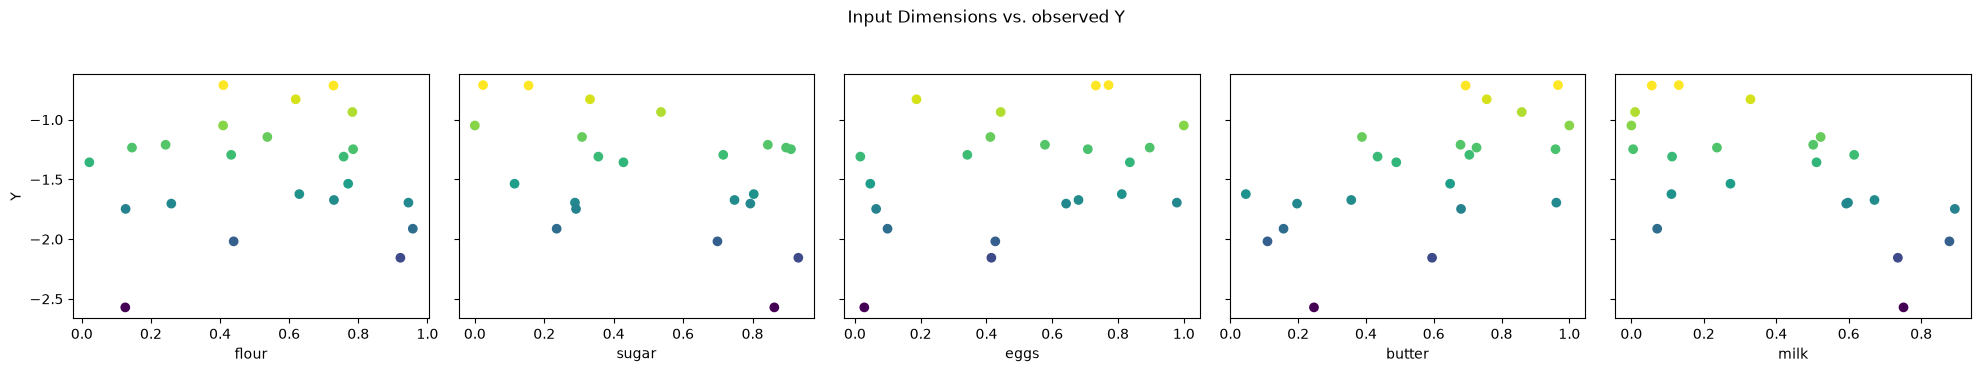

In [32]:
# Pairwise Scatter Plot, showing relationship of y for each input
fig, axes = plt.subplots(1, len(ingredient_names), figsize = (4 * len(ingredient_names), 3.5), sharey = True)
for ax, col in zip(axes, ingredient_names):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = 'viridis')
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

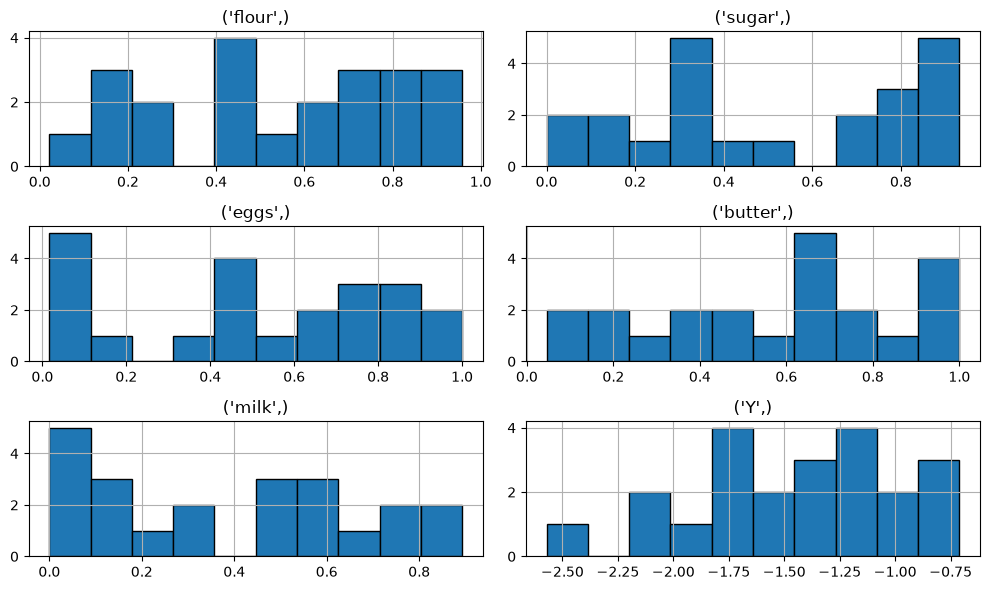

In [34]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [36]:
# Understanding Correlation between each input with y
print("Correlation of each input with y:\n")

for i, lab in enumerate(ingredient_names):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(flour, Y) = 0.03362013261862502
 corr(sugar, Y) = -0.4544703243846813
 corr(eggs, Y) = 0.35002972111707553
 corr(butter, Y) = 0.6015947662964503
 corr(milk, Y) = -0.6266316682195215


<Axes: xlabel='None', ylabel='None'>

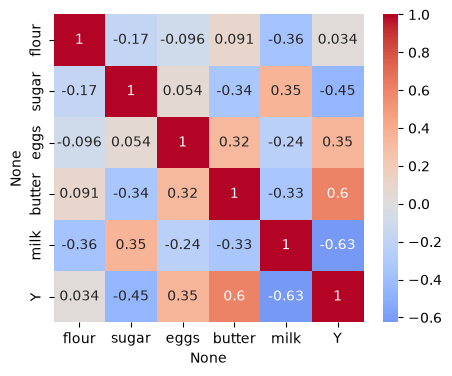

In [38]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

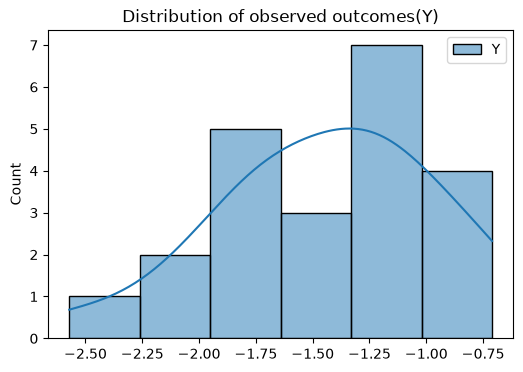

In [40]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [43]:
# Define the kernel and initialise the GP model
n, d       = X.shape
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * d, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [45]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.87**2 * RBF(length_scale=[7.93, 5.37, 1.06, 3.3, 4.41]) + WhiteKernel(noise_level=0.042)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [49]:
# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (10000, d))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.11287536 0.02505852 0.29440539 0.9800298  0.01091711]
UCB Score: 5.138529e-01


# Week 2: Define a consolidated Bayesian Function 
1. Fit a GP surrogate (ARD-RBF + white noise) on all data so far
2. Optimise the UCB acquisition function with multi-start **L-BFGS-B**
3. Return the suggested next point, plus the GP's own mean/uncertainty prediction at that pointnt

In [52]:
# For Week - 2, decreasing the value of beta
beta         = 2.0

def suggest_next_bo_point(X, Y, beta, n_restarts = 20, seed = 42):

    n_dims = X.shape[1]

    kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.5] * n_dims, length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1.0))
    
    gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

    gpr.fit(X, Y)

    def ucb(X_query, gpr, beta):
        mu, sigma = gpr.predict(X_query, return_std = True)
        return mu + beta * sigma

    def neg_ucb(x, gpr, beta):
        # scipy.optimize.minimize only minimises, so we minimise -UCB to maximise UCB
        x      = x.reshape(1, -1)
        return -ucb(x, gpr, beta)[0]

    rng        = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    bounds     = [(0.0, 0.999999)] * n_dims

    for x0 in rng.uniform(0.0, 0.999999, size = (n_restarts, n_dims)):
        res    = minimize(neg_ucb, x0, args = (gpr, beta), bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            best_x   = res.x

    next_x = np.clip(best_x, 0.0, 0.999999,)
    mu_next, sigma_next = gpr.predict(next_x.reshape(1, -1), return_std = True)

    return next_x, -best_val, gpr, mu_next[0], sigma_next[0]


In [54]:
next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta = beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 2 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")

Learned kernel: 2.87**2 * RBF(length_scale=[7.93, 5.37, 1.06, 3.3, 4.41]) + WhiteKernel(noise_level=0.042)

Week 2 suggested query point   :  [0.         0.         0.38371997 0.999999   0.        ]
GP predicted mean at this point:  -0.106277
GP predicted std  at this point:  0.301437
UCB value                      :  0.496597

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.5803  (0 would mean re-querying an existing point)


# Week 2: Visualisation

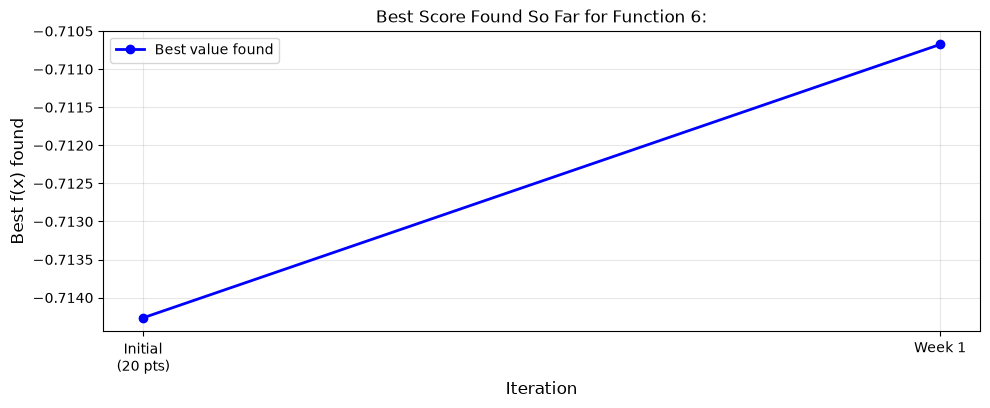

In [57]:
# Convergence: best value found so far, round by round
best_so_far  = [ np.max(Y[:20]),   # best among the original 20 points
                 np.max(Y[:21]),   # best after Week 1's point was appended
               ]

round_labels = ["Initial\n(20 pts)", "Week 1"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)

ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6:")
plt.show()


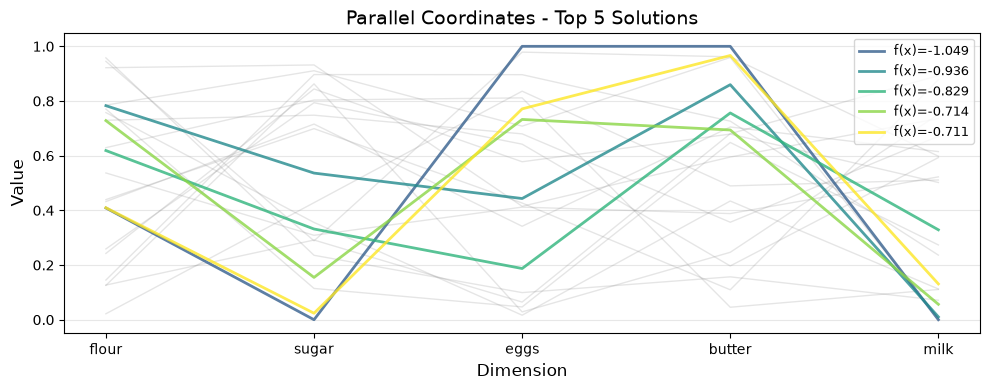

In [59]:
# Parallel coordinates: see all 5 ingredients at once, highlighting the top samples
fig, ax = plot_parallel_coordinates(X, Y, n_best = 5)
ax.set_xticklabels(ingredient_names)
plt.show()

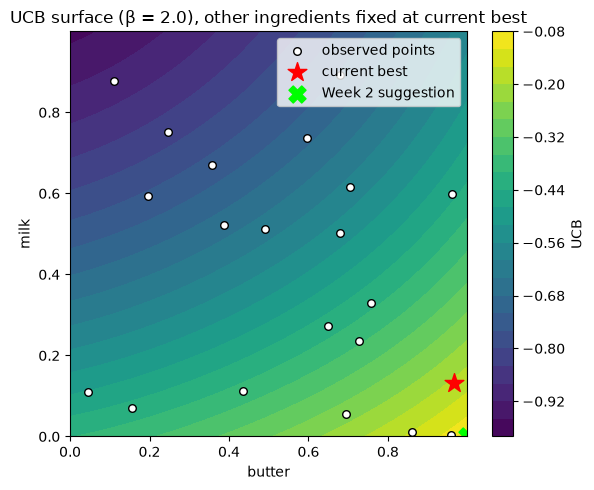

In [61]:
# UCB surface as a 2D slice through the current best point (5D can't be plotted directly, so we fix 3 ingredients at the current best
#  and sweep 2 of them on a grid)

def ucb(X_query, gpr, beta):
    mu, sigma   = gpr.predict(X_query, return_std = True)
    return mu + beta * sigma

x_best = X[np.argmax(Y)]
dim_a, dim_b    = 3, 4  # butter vs milk
resolution      = 60
grid            = np.linspace(0.0, 0.999999, resolution)
A, B            = np.meshgrid(grid, grid)

X_grid = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface      = ucb(X_grid, gpr, beta = 2.0).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s = 30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 2 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (β = {beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Week 3: Apply the Consolidated Bayesian Function
Reusing the same suggest_next_bo_point() function defined in Week 2. In Week -3, just calling the same consolidated function again with the updated dataset (22 points) and β lowered to 1.5.

In [69]:
beta = 1.5

next_x, ucb_val, gpr, mu_next, sigma_next = suggest_next_bo_point(X, Y, beta=beta)

print("Learned kernel:", gpr.kernel_)
print()
print(f"Week 3 suggested query point   :  {next_x}")
print(f"GP predicted mean at this point:  {mu_next:.6f}")
print(f"GP predicted std  at this point:  {sigma_next:.6f}")
print(f"UCB value                      :  {ucb_val:.6f}")
print()
print("Distance of this point from the nearest existing observation:")
dists = np.linalg.norm(X - next_x, axis = 1)
print(f"Nearest Neighbour Distance = {dists.min():.4f}  (0 would mean re-querying an existing point)")
print()
print(f"Current best so far: y = {Y.max():.6f} at x = {X[np.argmax(Y)]}")

Learned kernel: 2.87**2 * RBF(length_scale=[7.93, 5.37, 1.06, 3.3, 4.41]) + WhiteKernel(noise_level=0.042)

Week 3 suggested query point   :  [0.         0.         0.39298399 0.999999   0.        ]
GP predicted mean at this point:  -0.104749
GP predicted std  at this point:  0.300564
UCB value                      :  0.346097

Distance of this point from the nearest existing observation:
Nearest Neighbour Distance = 0.5742  (0 would mean re-querying an existing point)

Current best so far: y = -0.710675 at x = [0.409594 0.023713 0.771229 0.96649  0.130973]


# Week 3: Kernel-Length-Scale Diagnostic Check

In [82]:
rbf_part = gpr.kernel_.k1.k2  # (Constant * RBF) + White -> k1 = Constant*RBF, k1.k2 = RBF
print("Fitted ARD length-scales after 22 points:\n")
for name, ls in zip(ingredient_names, rbf_part.length_scale):
    print(f"  {name:8s}: {ls:.3f}")

print()
print("Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),")
print("to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.")

Fitted ARD length-scales after 22 points:

  flour   : 7.931
  sugar   : 5.372
  eggs    : 1.056
  butter  : 3.301
  milk    : 4.410

Comparing this to Week 1's length-scales (flour = 0.509, sugar = 1.070, eggs = 1.163,butter = 1.235, milk = 1.316),
to see whether the ranking of 'important' ingredients has moved now that Week 2's underperforming corner point is included.


# Week 3: Visualisation

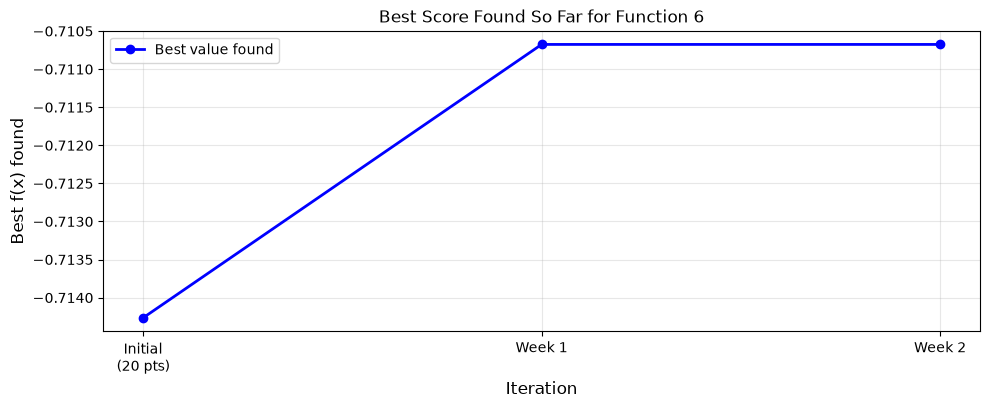

In [85]:
# Week 3: Convergence plot, including Week 2 output
best_so_far = [
    np.max(Y[:20]),   # best among the original 20 points
    np.max(Y[:21]),   # best after Week 1's point was appended
    np.max(Y[:22]),   # best after Week 2's point was appended (unchanged -- it was worse)
]
round_labels = ["Initial\n(20 pts)", "Week 1", "Week 2"]

fig, ax      = plot_convergence(range(len(best_so_far)), best_so_far)
ax.set_xticks(range(len(best_so_far)))
ax.set_xticklabels(round_labels)
ax.set_title("Best Score Found So Far for Function 6")
plt.show()

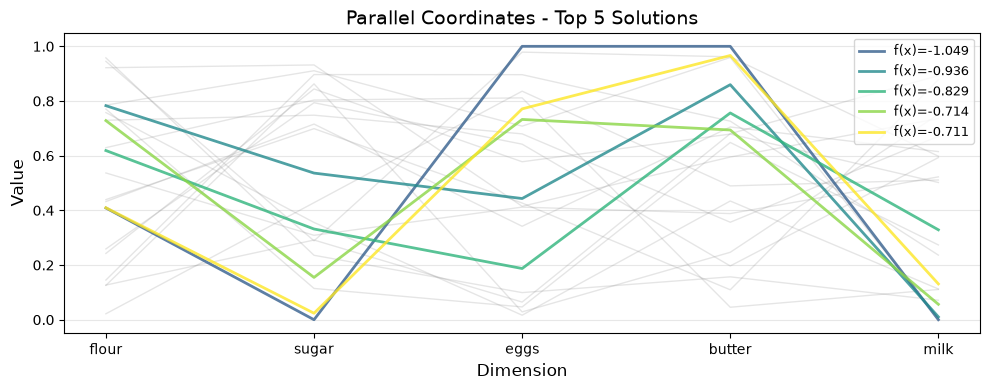

In [87]:
# Week 3: parallel coordinates, updated with all 22 points 
fig, ax = plot_parallel_coordinates(X, Y, n_best=5)
ax.set_xticklabels(ingredient_names)
plt.show()

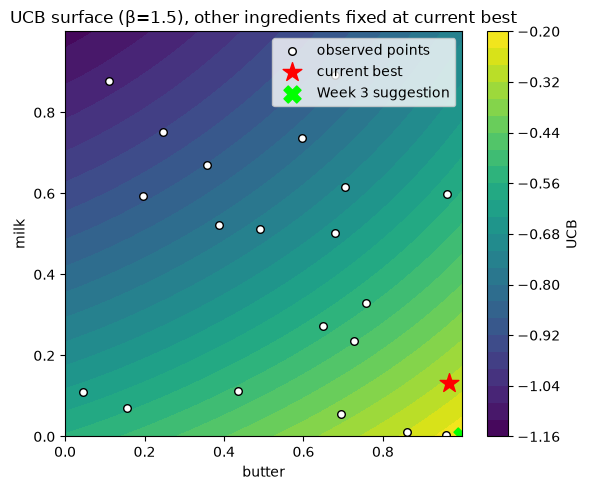

In [89]:
# Week 3: UCB surface slice through the current best point, beta = 1.5 
def ucb(X_query, gpr, beta):
    mu, sigma = gpr.predict(X_query, return_std=True)
    return mu + beta * sigma

x_best       = X[np.argmax(Y)]
dim_a, dim_b = 3, 4  # butter vs milk
resolution   = 60
grid         = np.linspace(0.0, 0.999999, resolution)
A, B         = np.meshgrid(grid, grid)

X_grid       = np.tile(x_best, (resolution * resolution, 1))
X_grid[:, dim_a] = A.ravel()
X_grid[:, dim_b] = B.ravel()

ucb_surface = ucb(X_grid, gpr, beta=beta).reshape(resolution, resolution)

plt.figure(figsize = (6, 5))
cf = plt.contourf(A, B, ucb_surface, levels = 25, cmap = "viridis")
plt.colorbar(cf, label = "UCB")
plt.scatter(X[:, dim_a], X[:, dim_b], c = "white", edgecolor = "black", s=30, label = "observed points")
plt.scatter(x_best[dim_a], x_best[dim_b], c = "red", marker = "*", s = 200, label = "current best")
plt.scatter(next_x[dim_a], next_x[dim_b], c = "lime", marker = "X", s = 150, label = "Week 3 suggestion")
plt.xlabel(ingredient_names[dim_a]); plt.ylabel(ingredient_names[dim_b])
plt.title(f"UCB surface (\u03b2={beta}), other ingredients fixed at current best")
plt.legend()
plt.tight_layout()
plt.show()

# Portal Submission 

In [98]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1):",'0.409594-0.023713-0.771229-0.966490-0.130973')
print("Points to be submitted(Week 2):",'0.408768-0.000000-0.999999-0.999999-0.000000')
print(f"Points to be submitted(Week 3): {submission_str}")

Points to be submitted(Week 1): 0.409594-0.023713-0.771229-0.966490-0.130973
Points to be submitted(Week 2): 0.408768-0.000000-0.999999-0.999999-0.000000
Points to be submitted(Week 3): 0.000000-0.000000-0.392984-0.999999-0.000000
